In [97]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import math

def parse_dnr(d):
    """
    'D0411' -> 411
    'D1354' -> 1354
    """
    s = str(d).strip()
    if not s or not s.startswith("D"):
        return None
    digits = s[1:].lstrip("0")  # remove 'D' and leading zeros
    if digits == "":
        return None
    return int(digits)


def compute_ct_diagnostics(
    merged: pd.DataFrame,
    min_points: int = 50,
    min_current: float = 5.0,
) -> pd.DataFrame:
    """
    Per-substation diagnostics to detect CT scaling vs unmetered load.

    Expects columns in merged:
      substation_id, ts, I_total_sm, I_total_jn, n_mps, per_completed

    Assumes:
      - Janitza should be an upper bound for true current
        → in a physically consistent situation, I_total_sm <= I_total_jn
        (ignoring noise / mapping mistakes).
    """
    rows = []

    for sid, g in merged.groupby("substation_id"):
        g = g.copy()

        # Filter out very low currents (ratios get crazy near zero)
        mask = (g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)
        g = g[mask]
        if len(g) < min_points:
            continue  # not enough data

        x = g["I_total_sm"].values
        y = g["I_total_jn"].values

        # --- 1) Physical sanity: how often is SMD > Janitza? ---
        # This should basically never happen if topology + CT are correct
        sm_gt_jn = (g["I_total_sm"] > g["I_total_jn"])
        frac_sm_gt_jn = sm_gt_jn.mean()

        # --- 2) Unconstrained linear fit: y ≈ alpha * x + beta ---
        # (useful for R² / "does it look like a line?")
        alpha_ls, beta = np.polyfit(x, y, 1)

        y_pred = alpha_ls * x + beta
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

        # Correlation (shape similarity)
        corr = g["I_total_jn"].corr(g["I_total_sm"])

        # --- 3) Ratio-based view: y/x distribution ---
        ratio = g["I_total_jn"] / g["I_total_sm"]
        ratio = ratio.replace([np.inf, -np.inf], np.nan).dropna()
        ratio_median = float(ratio.median()) if not ratio.empty else np.nan
        ratio_std = float(ratio.std()) if not ratio.empty else np.nan
        ratio_min = float(ratio.min()) if not ratio.empty else np.nan
        ratio_p05 = float(ratio.quantile(0.05)) if len(ratio) > 0 else np.nan

        # --- 4) "CT scaling" factor under your physical constraint ---
        # Idea:
        #   - If JD is an upper bound, any scaling alpha must satisfy:
        #       alpha * I_total_sm <= I_total_jn  for all timestamps
        #     → alpha <= min_t (I_total_jn / I_total_sm) = ratio_min
        #
        #   - We also want alpha close to the "best" slope.
        #   - So we take the OLS slope *through origin* (no intercept)
        #     and then clip it to respect the constraint.
        #
        # OLS with intercept 0 : alpha0 = sum(x*y) / sum(x^2)
        if np.sum(x**2) > 0:
            alpha0 = float(np.sum(x * y) / np.sum(x**2))
        else:
            alpha0 = np.nan

        # Use a slightly robust upper bound: 5% quantile instead of raw min,
        # to avoid one glitch forcing alpha too low.
        # Physically allowed max alpha:
        alpha_max_phys = ratio_p05  # or ratio_min if you want it really strict

        if (not np.isnan(alpha0)) and (not np.isnan(alpha_max_phys)):
            # Constrained CT factor: best slope, but not larger than physical max
            alpha_ct = min(alpha0, alpha_max_phys)
        else:
            alpha_ct = np.nan

        # --- 5) Smart-meter completeness & expected alpha from coverage ---
        if "per_completed" in g:
            per_completed = float(g["per_completed"].max())
            # If someone stored it as 0–100, convert to 0–1
            if per_completed > 1.5:
                per_completed = per_completed / 100.0
        else:
            per_completed = np.nan

        n_mps = float(g["n_mps"].max()) if "n_mps" in g else np.nan

        # Expected alpha purely from missing meters:
        # per_completed = 0.9 → expected JD/SMD ≈ 1 / 0.9 ≈ 1.11
        if per_completed and per_completed > 0:
            expected_alpha = 1.0 / per_completed
        else:
            expected_alpha = np.nan

        if expected_alpha and (not np.isnan(expected_alpha)) and (not np.isnan(alpha_ct)):
            alpha_over_expected = alpha_ct / expected_alpha
        else:
            alpha_over_expected = np.nan

        rows.append({
            "substation_id": sid,
            # Unconstrained regression fit (with intercept)
            "alpha_ls": alpha_ls,
            "beta": beta,
            "r2": r2,
            "corr": corr,
            # Physically constrained CT-like factor
            "alpha_ct": alpha_ct,
            "alpha0_through_origin": alpha0,
            "ratio_min": ratio_min,
            "ratio_p05": ratio_p05,
            "ratio_median": ratio_median,
            "ratio_std": ratio_std,
            # Coverage + expectation
            "per_completed": per_completed,
            "n_mps": n_mps,
            "expected_alpha_from_coverage": expected_alpha,
            "alpha_over_expected": alpha_over_expected,
            # Conservation violation diagnostics
            "frac_sm_gt_jn": frac_sm_gt_jn,
            "n_points": len(g),
        })

    return pd.DataFrame(rows)


def plot_substation_timeseries(merged, sid, alpha=None, max_points=2000):
    g = merged[merged["substation_id"] == sid].sort_values("ts")
    if len(g) > max_points:
        g = g.iloc[:max_points]

    plt.figure(figsize=(12, 4))
    plt.plot(g["ts"], g["I_total_jn"], label="Janitza I_total")
    plt.plot(g["ts"], g["I_total_sm"], label="Smartmeters I_total")

    if alpha is not None:
        plt.plot(g["ts"], alpha * g["I_total_sm"], "--", label=f"SMD * {alpha:.2f}")

    plt.title(f"Substation {sid} – total current")
    plt.xlabel("Time")
    plt.ylabel("Current [A]")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_substation_scatter(merged, sid, alpha=None):
    g = merged[merged["substation_id"] == sid]

    plt.figure(figsize=(5, 5))
    plt.scatter(g["I_total_sm"], g["I_total_jn"], s=5, alpha=0.3, label="JD vs SMD")

    max_i = max(g["I_total_sm"].max(), g["I_total_jn"].max())
    plt.plot([0, max_i], [0, max_i], "k--", label="JD = SMD")

    if alpha is not None:
        xs = np.linspace(0, max_i, 100)
        plt.plot(xs, alpha * xs, label=f"JD = {alpha:.2f}·SMD")

    plt.xlabel("SMD I_total [A]")
    plt.ylabel("JD I_total [A]")
    plt.title(f"Substation {sid} – scatter")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_scatter_grid(
    merged: pd.DataFrame,
    summary: pd.DataFrame,
    min_per_completed: float = 0.9,
    max_plots: int = 12,
    cols: int = 4,
    min_points: int = 50,
    min_current: float = 5.0,
):
    """
    Make a grid of scatter plots:
        x = I_total_sm (smartmeters)
        y = I_total_jn (Janitza)
    for multiple substations with per_completed >= min_per_completed.
    
    Needs:
      merged: rows with columns [substation_id, I_total_sm, I_total_jn, per_completed]
      summary: per-substation diagnostics from compute_ct_diagnostics().
    """

    # Filter to reasonably complete substations
    cand = summary[
        (summary["per_completed"] >= min_per_completed) &
        (summary["n_points"] >= min_points)
    ].copy()

    if cand.empty:
        print("No substations meet the per_completed and n_points filters.")
        return

    # Sort e.g. by alpha_over_expected so the “worst” ones come first
    cand = cand.sort_values("alpha_over_expected", ascending=False)

    # Limit how many we plot
    cand = cand.head(max_plots)

    n_plots = len(cand)
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)  # flatten in case rows/cols >1

    # Global limits to keep axes comparable
    global_max = 0.0

    # First pass: compute global max for axes
    for sid in cand["substation_id"]:
        g = merged[merged["substation_id"] == sid].copy()
        mask = (g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)
        g = g[mask]
        if g.empty:
            continue
        local_max = max(g["I_total_sm"].max(), g["I_total_jn"].max())
        global_max = max(global_max, local_max)

    if global_max == 0:
        print("All filtered substations have zero currents after filtering.")
        return

    # Second pass: actual plotting
    for ax, (_, row) in zip(axes, cand.iterrows()):
        sid = row["substation_id"]
        alpha = row["alpha_ct"] # trying this "alpha_over_expected" instead of "alpha_ct" since that is suppose to weigh in both coverage and CT issues
        per_completed = row["per_completed"]
        alpha_over_exp = row["alpha_over_expected"]
        r2 = row["r2"]

        g = merged[merged["substation_id"] == sid].copy()
        mask = (g["I_total_sm"].abs() > min_current) & (g["I_total_jn"].abs() > min_current)
        g = g[mask]
        if g.empty:
            ax.set_visible(False)
            continue

        # Scatter points
        ax.scatter(
            g["I_total_sm"],
            g["I_total_jn"],
            s=5,
            alpha=0.3,
        )

        # Diagonal JD = SMD
        xs = np.linspace(0, global_max, 100)
        ax.plot(xs, xs, "k--", linewidth=1, label="JD = SMD")

        # Fitted CT scaling line JD = alpha * SMD (ignore beta for visualization)
        ax.plot(xs, alpha * xs, linewidth=1, label=f"JD = {alpha:.2f}·SMD")

        ax.set_title(
            f"Sub {sid}\n"
            f"α={alpha:.2f}, r²={r2:.2f}\n"
            f"per={per_completed:.2f}, α/α_exp={alpha_over_exp:.2f}"
        )

        ax.set_xlim(0, global_max)
        ax.set_ylim(0, global_max)

    # Hide unused axes (if any)
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    # Axis labels only on outer edges to avoid clutter
    for i, ax in enumerate(axes[:n_plots]):
        row_idx = i // cols
        col_idx = i % cols
        if row_idx == rows - 1:
            ax.set_xlabel("I_total_sm [A]")
        if col_idx == 0:
            ax.set_ylabel("I_total_jn [A]")

    plt.suptitle(
        f"JD vs SMD scatter – substations with per_completed ≥ {min_per_completed}",
        y=0.98,
    )
    plt.tight_layout()
    plt.show()


# Paths assuming notebook is in src/phasebalance
sm_path = "../data/smartmeter_15min_all_from_devices_20251101_20251103_test.parquet"
jn_path = "../data/janitza_15min_all_20251101_1200_20251103_1200.parquet"

df_sm = pd.read_parquet(sm_path)
df_jn = pd.read_parquet(jn_path)

# List of substations / dnr_str values you want to exclude
exclude_dnr = ["D0006", "D1133","D1554"]  # add more here later
df_jn = df_jn[~df_jn["dnr_str"].isin(exclude_dnr)].copy()

df_jn["substation_id"] = df_jn["dnr_str"].map(parse_dnr)

# 2) Ensure timestamps are datetime
df_sm["ts"] = pd.to_datetime(df_sm["ts"])
df_jn["ts"] = pd.to_datetime(df_jn["ts"])

# 3) Sort for sanity
df_sm = df_sm.sort_values(["substation_id", "ts"])
df_jn = df_jn.sort_values(["substation_id", "ts"])

# Force both ts columns to be UTC -> then drop timezone (naive but aligned)
df_sm["ts"] = pd.to_datetime(df_sm["ts"], utc=True).dt.tz_localize(None)
df_jn["ts"] = pd.to_datetime(df_jn["ts"], utc=True).dt.tz_localize(None)

df_jn.head()


,ts,I_a,I_b,I_c,I_total,dnr_str,substation_id
192,2025-11-01 12:00:00,247.398941,205.307343,226.026489,678.732773,D0029,29
193,2025-11-01 12:15:00,233.248749,210.674438,227.559341,671.482529,D0029,29
194,2025-11-01 12:30:00,224.983154,207.986435,221.484894,654.454483,D0029,29
195,2025-11-01 12:45:00,219.442444,201.459366,213.465912,634.367722,D0029,29
196,2025-11-01 13:00:00,216.059448,201.753647,214.963669,632.776764,D0029,29


### CT diagnostics: meaning of the returned columns

For each **substation**, `compute_ct_diagnostics` returns one row with the following
diagnostics. The goal is to separate **CT scaling issues** from **missing meters /
unmetered load / other weirdness**.

---

#### Basic regression between SMD and JD

- **`alpha_ls`**  
  Slope of the unconstrained linear regression  
  $
  I_\text{JD} \approx \alpha_\text{ls} \cdot I_\text{SM} + \beta
  $  
  If everything was perfect and fully metered, we’d expect `alpha_ls ≈ 1`.  
  Values > 1 mean JD is typically larger than SMD; < 1 means the opposite.

- **`beta`**  
  Intercept of that regression. Roughly: JD current when SMD current is 0.  
  In a pure scaling (CT) error scenario this should be close to 0.  
  A big `beta` can suggest some “baseline” unmetered load or bias.

- **`r2`**  
  Coefficient of determination (R²) of the regression.  
  Measures how well a *linear* model with slope and intercept explains JD from SMD.
  Values close to 1 mean “JD is basically a straight-line function of SMD”.

- **`corr`**  
  Pearson correlation between `I_total_jn` and `I_total_sm`.  
  This is a pure shape similarity measure (ignores absolute scale).  
  Values close to 1 mean the time profiles look almost identical.

---

#### Ratio JD / SMD over time

These are based on the pointwise ratio  
$
\text{ratio}_t = \frac{I_{\text{JD},t}}{I_{\text{SM},t}}
$
after filtering out very small currents.

- **`ratio_median`**  
  Typical JD/SMD scale factor. If JD is usually about 1.5× SMD,  
  then `ratio_median ≈ 1.5`.

- **`ratio_std`**  
  Variability of the JD/SMD ratio.  
  Small value → ratio is very stable → looks like a fixed scaling factor.  
  Large value → ratio jumps around → likely more than just a CT scale issue.

- **`ratio_min`**  
  Minimum observed JD/SMD. Normally should be ≥ 1 if JD is an upper bound.
  Very small values can indicate timestamps where SMD > JD or bad data.

- **`ratio_p05`**  
  5th percentile of the ratio distribution (a “robust minimum”).  
  Used as a safer lower bound than `ratio_min` so one glitch doesn’t dominate.

---

#### CT scaling estimates

- **`alpha0_through_origin`**  
  Slope of the regression **forced through (0,0)**:  
  $
  \alpha_0 = \frac{\sum x y}{\sum x^2}
  $  
  This is the “best” pure multiplicative factor relating SMD to JD,
  assuming no intercept. Think of this as the raw CT scale estimate.

- **`alpha_ct`**  
  **Physically constrained** CT-like scaling factor.  
  We want a factor `alpha` such that:
  - It’s close to `alpha0_through_origin`, **and**
  - It respects the physical constraint `alpha * I_SM ≤ I_JD`.

  To enforce that, we cap `alpha` using the robust lower bound:
  $
    \alpha_\text{ct} = \min(\alpha_0, \text{ratio\_p05})
  $  
  This is the factor you’d use if you want to scale SMD up towards JD
  without letting it overshoot the Janitza readings.

---

#### Coverage and expected scaling

- **`per_completed`**  
  Smart-meter rollout completeness for this substation (0–1).  
  Example: 0.9 means 90% of meters are present in SMD, 10% missing/unmetered.

- **`n_mps`**  
  Number of metering points (smart meters) contributing to this substation.

- **`expected_alpha_from_coverage`**  
  What the JD/SMD ratio would be **if the only issue was missing meters**,  
  assuming missing customers have similar behaviour to the ones we see:
  $
  \text{expected\_alpha} = \frac{1}{\text{per\_completed}}
  $
  Example: per_completed = 0.8 → expected JD/SMD ≈ 1 / 0.8 = 1.25.

- **`alpha_over_expected`**  
  How much larger the CT factor is than what coverage alone would explain:
  $
  \alpha_\text{over\_expected} = \frac{\alpha_\text{ct}}{\text{expected\_alpha}}
  $  
  - ≈ 1 → mismatch can be explained mostly by missing meters.  
  - >> 1 → JD still much bigger than SMD even after accounting for per_completed  
    → strong hint of CT mis-scaling (or some other systematic error).

---

#### Physical consistency

- **`frac_sm_gt_jn`**  
  Fraction of timestamps where `I_total_sm > I_total_jn`.  
  If Janitza really is the “ground truth” upper bound, this should be near 0.  
  High values mean: topology issue, JD under-reading, SMD over-reading, etc.

- **`n_points`**  
  Number of time samples used for this substation **after** filtering out low
  currents. This is the effective sample size for all the stats above.


In [98]:
df_sm.head()

,substation_id,ts,I_a,I_b,I_c,I_total,n_mps,per_completed
0,6,2025-11-01 12:00:00,621.950,301.675,315.670,1239.295,286,0.667442
1,6,2025-11-01 12:15:00,608.390,308.090,305.570,1222.050,286,0.667442
2,6,2025-11-01 12:30:00,642.790,292.250,324.450,1259.490,286,0.667442
3,6,2025-11-01 12:45:00,630.800,291.240,330.670,1252.710,286,0.667442
4,6,2025-11-01 13:00:00,613.115,282.385,292.025,1187.525,286,0.667442


In [107]:

# Make a common substation_id column on Janitza side
# Here I simply rename dnr_str -> substation_id.
# If your smartmeter substation_id is numeric and Janitza is like "D0579",
# you might need to adjust this mapping (e.g. strip 'D' and leading zeros).
df_jn_use = df_jn.copy()

# Ensure both IDs are strings so they can match
df_sm_use = df_sm.copy()
df_sm_use["substation_id"] = df_sm_use["substation_id"].astype(str)
df_jn_use["substation_id"] = df_jn_use["substation_id"].astype(str)

# Keep only needed columns and rename totals
df_sm_use = df_sm_use[["substation_id", "ts", "I_total", "n_mps", "per_completed"]]
df_sm_use = df_sm_use.rename(columns={"I_total": "I_total_sm"})

df_jn_use = df_jn_use[["substation_id", "ts", "I_total"]]
df_jn_use = df_jn_use.rename(columns={"I_total": "I_total_jn"})

# Merge on substation_id + timestamp
merged = (
    df_sm_use
    .merge(df_jn_use, on=["substation_id", "ts"], how="inner")
    .dropna(subset=["I_total_sm", "I_total_jn"])
)

print("Merged shape:", merged.shape)


Merged shape: (11328, 6)


In [100]:
summary = compute_ct_diagnostics(merged)
summary.head()

,substation_id,alpha_ls,beta,r2,corr,alpha_ct,alpha0_through_origin,ratio_min,ratio_p05,ratio_median,ratio_std,per_completed,n_mps,expected_alpha_from_coverage,alpha_over_expected,frac_sm_gt_jn,n_points
0,1021,0.777677,9.809139,0.930738,0.964748,0.735138,0.812360,0.638034,0.735138,0.813888,0.056134,0.166667,1.0,6.000000,0.122523,0.994792,192
1,1025,0.978492,-17.263513,0.980269,0.990085,0.832900,0.917316,0.777216,0.832900,0.898107,0.047730,0.850000,68.0,1.176471,0.707965,0.968750,192
2,1029,1.450465,-91.291613,0.902406,0.949951,1.130755,1.290676,1.086497,1.130755,1.274138,0.098430,0.930233,160.0,1.075000,1.051865,0.000000,192
3,1030,1.214066,29.712920,0.976378,0.988118,1.166952,1.253019,1.071212,1.166952,1.254556,0.063174,0.893750,143.0,1.118881,1.042963,0.000000,192
4,1049,0.331803,-21.376944,0.863954,0.929491,0.241315,0.306203,0.222026,0.241315,0.302958,0.036051,0.981873,322.0,1.018462,0.236940,1.000000,192


In [109]:
# Stations where the physical assumption is mostly OK
ok_phys = summary[summary["frac_sm_gt_jn"] < 0.01]

# Among those, CT suspects (CT factor much larger than coverage alone explains)
ct_suspects = ok_phys[
    (ok_phys["per_completed"] > 0.9) &          # high coverage
    (ok_phys["r2"] > 0.9)                  # shape matches
].sort_values("alpha_over_expected", ascending=False)

ct_suspects[[
    "substation_id",
    "alpha_ct",
    "expected_alpha_from_coverage",
    "alpha_over_expected",
    "per_completed",
    "r2",
    "frac_sm_gt_jn",
    "n_points",
]]


,substation_id,alpha_ct,expected_alpha_from_coverage,alpha_over_expected,per_completed,r2,frac_sm_gt_jn,n_points
15,1364,1.661106,1.013308,1.639291,0.986867,0.984648,0.0,192
31,1482,1.237807,1.029412,1.202441,0.971429,0.941888,0.0,191
22,1399,1.148916,1.056782,1.087183,0.946269,0.953637,0.0,192
46,411,1.142817,1.064039,1.074036,0.939815,0.970544,0.0,192
2,1029,1.130755,1.075000,1.051865,0.930233,0.902406,0.0,192
23,1400,1.060357,1.083871,0.978305,0.922619,0.932816,0.0,192


Example CT-suspect substation: 1364 alpha = 1.6392907092138693


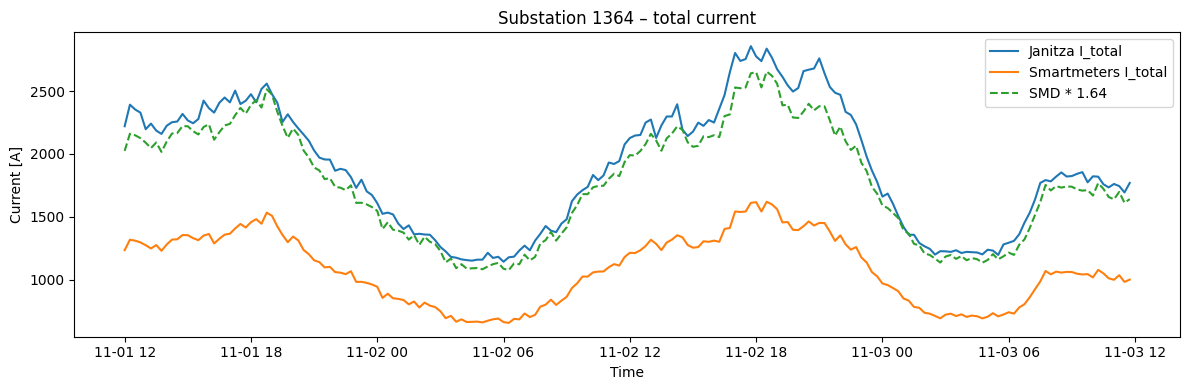

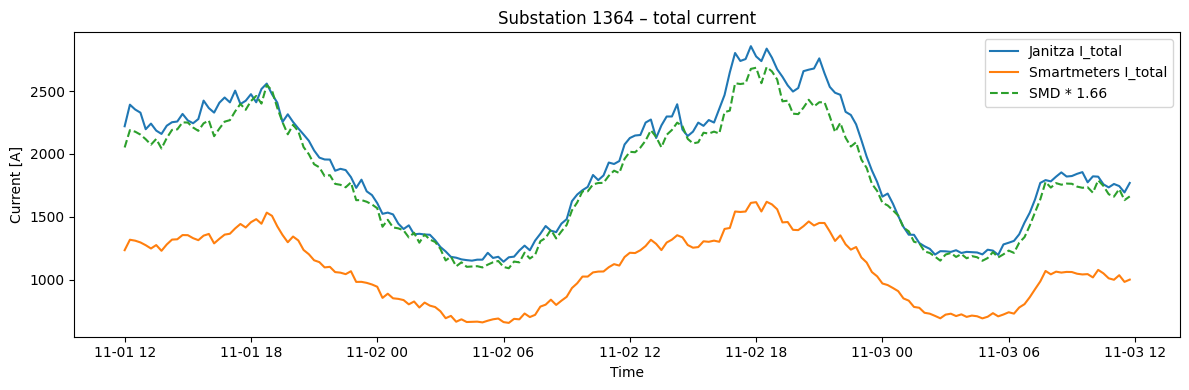

In [106]:
if not ct_suspects.empty:
    sid_example = ct_suspects.iloc[0]["substation_id"]
    alpha_example = ct_suspects.iloc[0]["alpha_over_expected"] #alpha_ct
    print("Example CT-suspect substation:", sid_example, "alpha =", alpha_example)

    plot_substation_timeseries(merged, sid_example, alpha=alpha_example)
    alpha_example = ct_suspects.iloc[0]["alpha_ct"] #alpha_ct
    plot_substation_timeseries(merged, sid_example, alpha=alpha_example)
    #plot_substation_scatter(merged, sid_example, alpha=alpha_example)


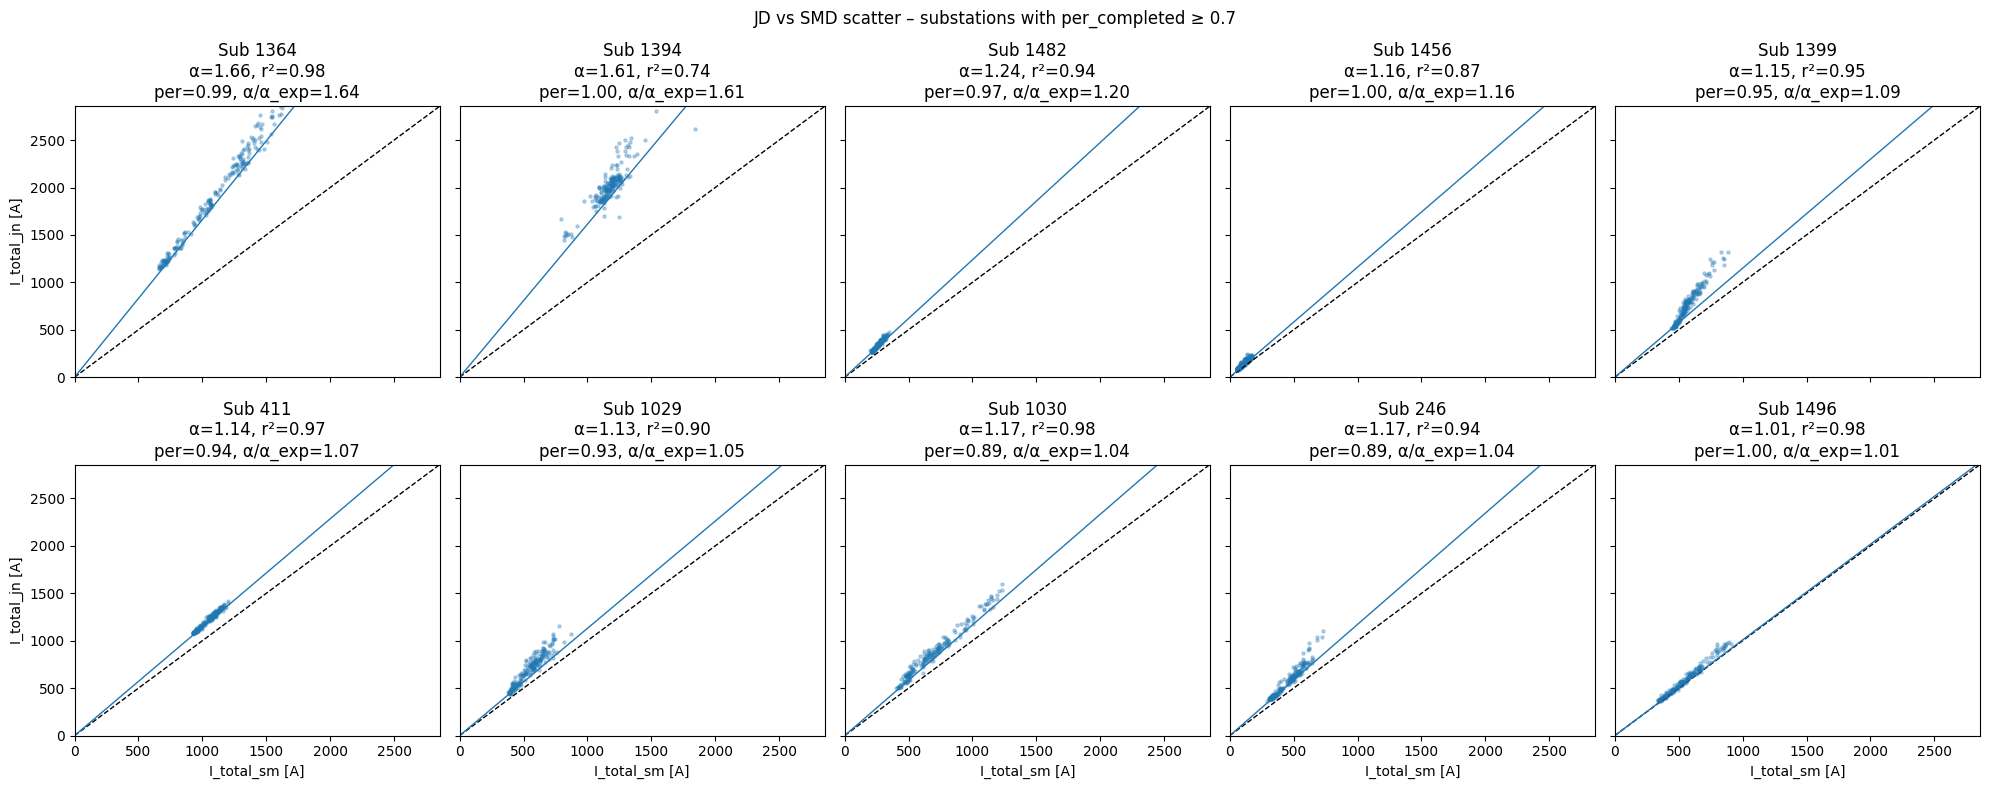

In [103]:
plot_scatter_grid(
    merged=merged,
    summary=summary,
    min_per_completed=0.7,
    max_plots=10,
    cols=5,
)


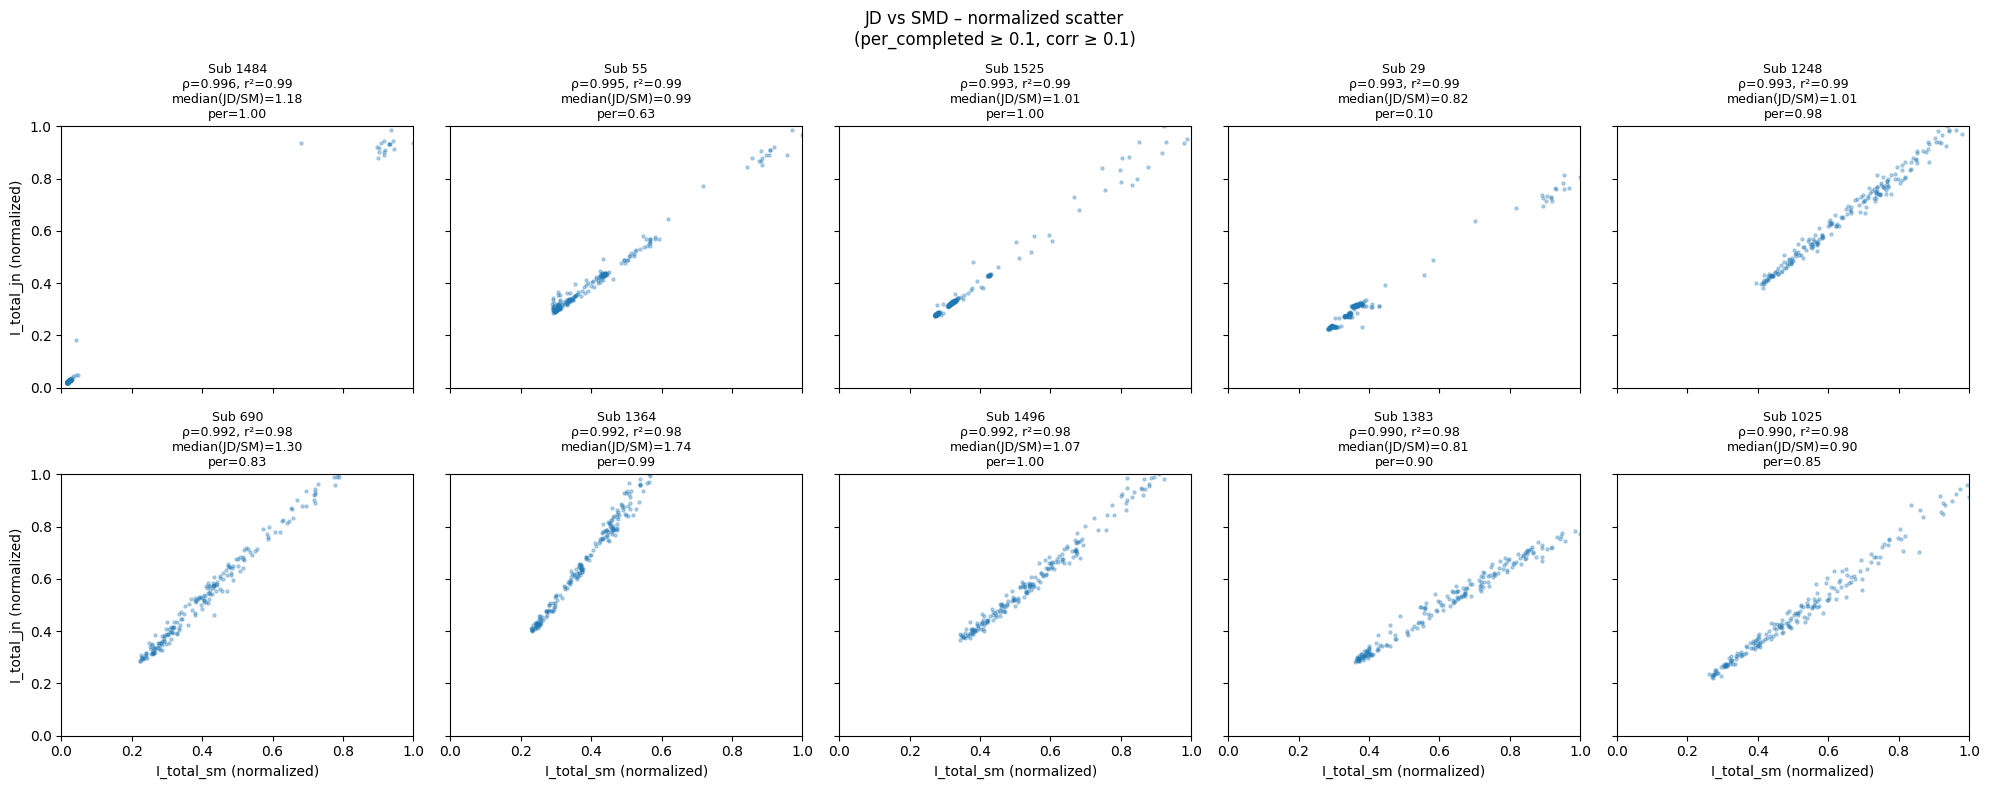

In [104]:
def plot_corr_grid_smd_vs_jn_normalized(
    merged: pd.DataFrame,
    summary: pd.DataFrame,
    min_per_completed: float = 0.9,
    min_corr: float = 0.97,
    min_alpha_over_expected: float = 1.2,  # kept for compatibility, not used
    max_plots: int = 12,
    cols: int = 4,
    min_points: int = 50,
    min_current: float = 5.0,
):
    """
    Grid of *normalized* scatter plots:
        x = I_total_sm / scale_sub
        y = I_total_jn / scale_sub
    where scale_sub = max(I_total_sm, I_total_jn) for that substation.

    This keeps JD/SMD slope the same, but every panel is in ~[0,1]x[0,1],
    so small and big substations are equally readable.

    Titles show corr, median ratio, per_completed, etc.
    """

    # normalize per_completed to [0,1] if needed
    if summary["per_completed"].max() > 1.5:
        summary = summary.copy()
        summary["per_completed"] = summary["per_completed"] / 100.0

    # pick interesting substations: high coverage + decent correlation
    cand = summary[
        (summary["n_points"] >= min_points) &
        (summary["per_completed"] >= min_per_completed) &
        (summary["corr"] >= min_corr)
    ].copy()

    if cand.empty:
        print("No substations meet the filters.")
        return

    # sort by correlation (or whatever you like)
    cand = cand.sort_values("corr", ascending=False)

    cand = cand.head(max_plots)
    n_plots = len(cand)
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(4 * cols, 4 * rows),
        sharex=True,
        sharey=True,
    )
    axes = np.array(axes).reshape(-1)

    # plotting
    for ax, (_, row) in zip(axes, cand.iterrows()):
        sid = row["substation_id"]
        corr = row["corr"]
        r2   = row.get("r2", np.nan)
        perc = row.get("per_completed", np.nan)
        ratio_median = row.get("ratio_median", np.nan)

        g = merged[merged["substation_id"] == sid].copy()
        mask = (
            (g["I_total_sm"].abs() > min_current) &
            (g["I_total_jn"].abs() > min_current)
        )
        g = g[mask]
        if g.empty:
            ax.set_visible(False)
            continue

        # per-station scale so everything fits in [0,1]
        scale = max(g["I_total_sm"].max(), g["I_total_jn"].max())
        x_norm = g["I_total_sm"] / scale
        y_norm = g["I_total_jn"] / scale

        ax.scatter(x_norm, y_norm, s=5, alpha=0.3)

        ax.set_xlim(0, 1.0)
        ax.set_ylim(0, 1.0)

        # title: correlation + basic scale info
        title = f"Sub {sid}\nρ={corr:.3f}"
        if not np.isnan(r2):
            title += f", r²={r2:.2f}"
        if not np.isnan(ratio_median):
            title += f"\nmedian(JD/SM)={ratio_median:.2f}"
        if not np.isnan(perc):
            title += f"\nper={perc:.2f}"
        ax.set_title(title, fontsize=9)

    # hide unused axes
    for ax in axes[n_plots:]:
        ax.set_visible(False)

    # labels on outer plots
    for i, ax in enumerate(axes[:n_plots]):
        row_idx = i // cols
        col_idx = i % cols
        if row_idx == rows - 1:
            ax.set_xlabel("I_total_sm (normalized)")
        if col_idx == 0:
            ax.set_ylabel("I_total_jn (normalized)")

    plt.suptitle(
        "JD vs SMD – normalized scatter\n"
        f"(per_completed ≥ {min_per_completed}, corr ≥ {min_corr})",
        y=0.98,
    )
    plt.tight_layout()
    plt.show()


# Example call
plot_corr_grid_smd_vs_jn_normalized(
    merged=merged,
    summary=summary,
    min_per_completed=0.1,
    min_corr=0.1,
    min_alpha_over_expected=0.1,  # ignored now
    max_plots=10,
    cols=5,
)
